<a href="https://colab.research.google.com/github/jqzhou233/ml-nlp-projs/blob/main/Copy_of_%F0%9F%A4%96_BERT_Fine_Tuning_Stencil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 BERT Fine-Tuning for Sentiment Classification

Within this noble endeavor, thou shalt revisit yon task of sentiment classification - that very same pursuit which occupied thy labors in Assignment the First. Yet mark thee well! No longer shall ye employ the humble Bag of Words classifier, as though counting grain in a merchant's storehouse. Nay! Thou shalt instead construct a neural network of most cunning design, accomplished through the fine-tuning of a pre-trained language model - that magnificent creation known as BERT!

This approach to fashioning classifiers doth represent the very pinnacle of contemporary artistry in our field, the state-of-the-art as 'twere. Thus, by mastering this craft, thou shalt arm thyself most excellently for the multitude of Natural Language Processing challenges that Fortune may cast before thee in times yet to come!

The main learning objectives for this assignment are:
1. Understand how to design a basic experimental loop in PyTorch (loading data, training and evaluating a model).
2. Learn how to navigate the online documentation for PyTorch and HuggingFace.
3. Observe the effects of pre-training on model performance, and understand how "fine-tuning" differs from traditional model training.

**Note**: Mark well this purpose of the assignment: 'tis designed to teach thee the sacred art of consulting online documentation. The realm of deep learning libraries and codebases - particularly those dedicated to Natural Language Processing - doth evolve with great rapidity, as interest in the field burgeons and researchers increasingly make their code open to all who would partake of it.
Consequently, a skill most critical to successful practitioners - be they researchers or engineers—is the ability to learn independently how to write code through reading documentation and studying examples provided by others. Both [PyTorch](https://pytorch.org/docs/stable/index.html) and [HuggingFace](https://huggingface.co/docs) maintain documentation of excellent quality and clarity.

We require you to implement the training and testing loops from native PyTorch - **you may not use the HuggingFace Trainer API**. However, in reality, one would use the Trainer API - [here](https://huggingface.co/docs/transformers/main_classes/trainer) is the documentation for it.

# Imports and Package Installation

In [1]:
!pip install transformers torch evaluate tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00


In [2]:
import torch, codecs, random
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from evaluate import load as load_metric
from evaluate import EvaluationModule
from google.colab import output
import matplotlib.pyplot as plt
import numpy as np
from transformers import PreTrainedTokenizer
from torch.optim import Optimizer

output.enable_custom_widget_manager()

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

Mounted at /content/drive


## Part 1 - Baseline Model


### 1. Loading the dataset

We first need to load the dataset. For this assignment, we are using [the same dataset as in assignment 1](https://drive.google.com/file/d/1r_nI6lRAvYyeYrtGaVtHB18kR_fXb1_e/view?usp=sharing).

The dataset contains a total of 5000 labeled examples, the first 3000 of which should be used in training. The next 1000 should be used as a validation set, and the final 1000 should be used for testing. The `"text"` column of the `dataset` contains the raw text of each tweet, and the `"sentiment"` column contains the sentiment label (`"negative"`, `"neutral"`, or `"positive"`).

In [3]:
# TODO: update FOLDER below!
FOLDER = "/content/drive/My Drive/Colab Notebooks"
FILEPATH = f"{FOLDER}/Tweets_5K.csv"

In [4]:
import pandas as pd

dataset = pd.read_csv(FILEPATH, header=0, sep=",")

# TODO:
# X: list[string], should be a list of raw tweets (as text)
# y: list[int], a list of integer labels representing the sentiment column ("negative": 0, "neutral": 1, "positive": 2)
# Note that we are using different labels than from A1, since we can't use negative integer labels with our model!

label_map = {"negative": 0, "neutral": 1, "positive": 2}

X = dataset["text"].tolist()
y = dataset["sentiment"].map(label_map).tolist()

# TODO: split X and y into train/validation/test sets, use fixed indices (3000/1000/1000)
trainset, trainlabs = X[:3000], y[:3000]
valset, vallabs = X[3000:4000], y[3000:4000]
testset, testlabs = X[4000:5000], y[4000:5000]

Next, we need to define a child class to the PyTorch `Dataset` class such that we can customize it for our specific dataset, and also configure the tokenizer (which we'll initialize in a moment). The `__getitem__` function is what will be used to fetch all training examples by the eventual dataloader. `__getitem__` needs to tokenize the input tweets in the BERT fashion ([CLS] and [SEP] tokens need to be inserted as discussed in lecture, etc.)

In [12]:
class TweetDataset(torch.utils.data.Dataset):
    """A PyTorch Dataset for our tweets that can be iterated through using __getitem__"""
    def __init__(self,
                 tweets : list[str],
                 sentiments : list[int],
                 tokenizer : PreTrainedTokenizer
                 ) -> None:
        """
        Initializes the TweetDataset from a list of tweets, their corresponding sentiments, and a tokenizer.

        Attributes
        ----------
        tweets : list[str]
            A list of tweets, where each tweet is a string
        sentiments: list[int]
            A list of sentiments represented as integers ("negative": 0, "neutral": 1, "positive": 2)
        tokenizer : PreTrainedTokenizer
            Any PreTrainedTokenizer from HuggingFace that can be used to encode the string inputs for a model
        """
        self.tweets = tweets
        self.sentiments = sentiments
        self.tokenizer = tokenizer
        self.max_len = tokenizer.model_max_length

    def __len__(self) -> int:
        """
        Returns the number of tweets in the dataset.

        Returns:
        -------
        int
            Number of tweets in the dataset
        """
        return len(self.tweets)

    def __getitem__(self, index : int) -> dict[str, torch.Tensor]:
        """
        Retrieve a preprocessed data item (tweet) from the dataset at the specified index.
        This is called when iterating through a TweetDataset

        Parameters:
        ----------
        index : int
            The index of the data item to retrieve.

        Returns:
        -------
        dict[str, Any]
            A dictionary containing the preprocessed data for the given index.
            The dictionary includes the following keys:
            - "input_ids": Encoded input IDs for the tweet.
            - "attention_mask": Attention mask for the tweet.
            - "labels": Sentiment label as a PyTorch tensor.
        """
        tweet = str(self.tweets[index])
        sentiments = self.sentiments[index]

        # TODO: Encode the tweet using the tokenizer.
        # Read the HuggingFace documentation to figure out how to do so!
        # HINT: We want PyTorch ("pt") tensors as output.
        # Think about what we want for padding, truncation, and attention.
        # Don't forget the [CLS] and [SEP] tokens!

        encoded_tweet = self.tokenizer(
            tweet,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )

        # TODO: Return the outputs as a dict.
        # HINT: The labels should be a PyTorch tensor.
        # Make sure the input_ids and attention_mask are 1D arrays.

        return {
            "input_ids": encoded_tweet["input_ids"].squeeze(0),
            "attention_mask": encoded_tweet["attention_mask"].squeeze(0),
            "labels": torch.tensor(sentiments, dtype=torch.long)
        }

### 2. Tokenizer and DataLoader


Now that we have the `TweetDataset` class, you must construct the appropriate instances for our training, validation, and testing sets. After that, they must be used to construct PyTorch `DataLoader` instances (refer to the PyTorch [documentation](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html)).

At this point, batch sizes will have to be specified. This may require some experimentation, as the larger the batch size, the faster the models will train; however, they will also use more VMEM (Video Memory, like RAM but on a GPU). If you get an error during training or testing about running out of memory, reduce your batch sizes here.

Finally, we'll load the `distilbert-base-uncased` tokenizer from HuggingFace, which is the tokenizer that will be applied to the tweet text.

In [13]:
from transformers import AutoTokenizer
from torch.utils.data import DataLoader

# use this for the tokenizer argument of the TweetDataset
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# TODO: define the following TweetDataset objects - be careful to split the data as previously specified!
train_dataset = TweetDataset(trainset, trainlabs, tokenizer)
validation_dataset = TweetDataset(valset, vallabs, tokenizer)
test_dataset = TweetDataset(testset, testlabs, tokenizer)

# TODO: construct DataLoader objects from the TweetDataset objects
# HINT: remember that the TweetDataset class is a child class of torch.utils.data.Dataset
batch_size = 16

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

### 3. Loading the model

Here we use the HuggingFace transformers library to load the architecture of the `distilbert-base-uncased` model. This model (DistilBERT) is usually trained for a masked language modeling task; you can read more about the model [here](https://huggingface.co/distilbert-base-uncased). It's basically a smaller version of BERT, which was covered in lecture (it's been "[distilled](https://arxiv.org/abs/1910.01108)").

In [14]:
from transformers import AutoConfig, AutoModelForSequenceClassification

# TODO: get the distilbert-base-uncased AutoConfig with the CORRECT number of labels...
config = AutoConfig.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

# TODO: ...from which we can use AutoModelForSequenceClassification to instantiate
# an UNTRAINED version of the above model. Read the HuggingFace documentation
# to figure out how to do so!
untrained_model = AutoModelForSequenceClassification.from_config(config)

### 4. Evaluation loop

We need to define an evaluation function, such that we can measure a model's performance on a dataset.

For evaluation, there are a couple of steps that must be taken. For each batch in the evaluation set:
1. Apply the model on the batch (feedforward)
2. Obtain the predictions from the model output
3. Update the metrics and progress bar

HuggingFace documentation is your friend - the function signature is also provided.

**A note on logits**: Logits are unnormalized "probabilities"/predictions of a model. In this case, we have three classes: negative, neutral, or positive. Therefore, our model should output three "logits" per tweet, each one of which can be assigned to each of these classes. For our purposes, we can take the prediction of the model to be the class with the maximum of these three values (take the argmax across the outputs), but we could additionally determine the model's confidence in the input belonging to each class by applying a normalizing function to the logits such that the "probabilities" will add up to 1; one such function is softmax (no need to do this here)! The argmax of the logits is our class prediction, which can be compared to the "ground-truth" label. This may be useful when tracking metrics. Keep all of this in mind, since logits are what the DistilBERT's classifier will output.

**A note on PyTorch devices**: In PyTorch, tensor operations can be performed on devices, usually either CPUs or GPUs. Tensors can be set to certain devices (GPUs) to optimize calculations through parallelization. The operation to set a tensor to a device can be seen [here](https://pytorch.org/docs/stable/generated/torch.Tensor.to.html). Note that the returned tensor is now a copy if the device is changed. Setting a tensor to the device is necessary when using them for a model!

In the code below, the model's parameters are loaded onto the device we are using. This gives us a way to run models on the GPU by putting all of its parameters and computations on it.



In [22]:
# for any parameter named "device", pass the following variable:
device = torch.device("cuda") # can use 'cuda' for faster training but must 'Change runtime type'

# loading the model onto the device
untrained_model.to(device)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [23]:
def update_metrics(metrics: list[EvaluationModule], predictions: torch.Tensor, labels: torch.Tensor) -> None:
    """
    Update a list of metrics with new predictions and labels

    Parameters:
    -----------
    metrics : list[EvaluationModule]
        List of metrics.
    predictions : torch.Tensor
        Tensor of predictions of shape (batch_size, ...)
    labels : torch.Tensor
        Tensor of labels of shape (batch_size, ...)
    """
    # Nothing TODO here!
    # This updates metrics based on a batch of predictions and a batch of labels.
    for metric in metrics:
        metric.add_batch(predictions=predictions, references=labels)

def evaluate(model: torch.nn.Module,
             test_dataloader: torch.utils.data.DataLoader,
             device: torch.device,
             metric_strs : list[str]
             ) -> dict[str, float]:
    """
    Evaluate a PyTorch model

    Parameters:
    -----------
    model : torch.nn.Module
        The model to be evaluated.
    test_dataloader : torch.utils.data.DataLoader
        DataLoader containing testing examples.
    device : torch.device
        The device that the evaluation will be performed on.
    metric_strs : list[str]
        The names of HuggingFace metrics to use.

    Returns:
    --------
    dict[str, float]
        Dictionary of metric names mapped to their values.
    """
    # load metrics
    metrics = [load_metric(x) for x in metric_strs]
    model.eval()

    # we like progress bars :)
    progress_bar = tqdm(range(len(test_dataloader)))
    # HINT: progress_bar.update(1) should be used to show progress after an iteration

    # TODO: Fill in the evaluate function
    with torch.no_grad():
        for batch in test_dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=1)

            update_metrics(metrics, predictions.cpu(), labels.cpu())
            progress_bar.update(1)

    # compute and return metrics
    computed = {}
    for m in metrics:
        computed = {**computed, **m.compute()}

    return computed

### 5. Baseline performance:

*Warning: Be aware that since this is a Google Colab file/Jupyter notebook, sometimes it is necessary to re-execute the cell defining the models in order to "redefine" the model and therefore restart training from scratch.*

*In addition, sometimes "CUDA out of memory" errors are due to past models residing on the GPU. The easiest way to fix this is to restart the Colab runtime (CTRL + M + .), or to run a cell that deletes models (`del <model>`). A batch size of 32 for training should generally be small enough such that models train without memory issues. To change the batch size, modify the `batch_size` parameter passed when initializing the `DataLoader`.*

Now that we have an untrained model, our dataset, and an evaluation function, we can evaluate the model to find our baseline accuracies!

The next cell contains some code to make nice accuracy plots.

In [24]:
def make_plots(perfs: list[float], names: list[str]) -> None:
    """
    Create bar plots for performance metrics.

    Parameters:
    -----------
    perfs : list[float]
        List of performance values (e.g., accuracies).
    names : list[str]
        List of names for the corresponding performance metrics.
    """
    # Nothing TODO here
    for perf, name in zip(perfs, names):
        print(f"{name} accuracy: {perf}")
    plt.bar(np.arange(len(perfs)), perfs)
    plt.xticks(np.arange(len(names)), names)
    plt.show()

Now, let's execute our evaluation loop on the testing set. In terms of metrics, we'll only keep track of accuracy for now; however, you can add others to the metric list (check the HuggingFace evaluate documentation).


We should see that the baseline (expectedly) performs poorly.

  0%|          | 0/63 [00:00<?, ?it/s]

Baseline accuracy: 0.308


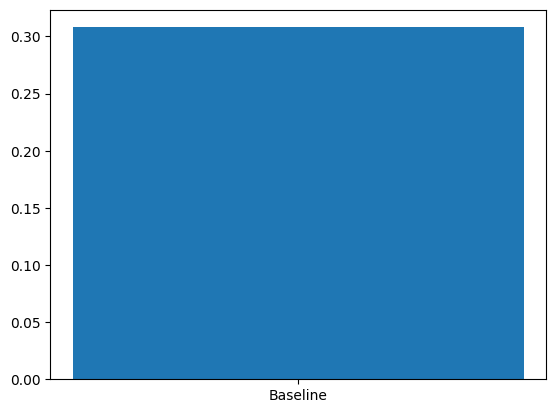

In [25]:
metrics = ["accuracy"]
# TODO: evaluate on the testing set
baseline_result = evaluate(
    untrained_model,
    test_dataloader,
    device,
    metrics
)["accuracy"]

# now, plot! do not modify the following:
results = [baseline_result]
names = ["Baseline"]
make_plots(results, names)

## Part 2 - Model trained from scratch




### 1. Defining the training loop:

The training loop follows similar steps to the evaluation loop.

For each batch in each epoch:
1. Apply the model on the batch inputs (feedforward)
2. Obtain the predictions, as well as the labels
3. Compare the predictions with the labels and calculate the loss
4. Backpropagate the loss and obtain gradients for all parameters
5. Update the optimizer and learning rate
6. Record the desired metrics based on the outputs and labels

In addition to this, we'd like to keep track of some metrics during each epoch, and at the end of an epoch we want to run an evaluation on the validation set (you can use the evaluation loop!). Specifically, we want to know the training accuracy (accuracy measured against the training set) and validation accuracy - they can be reported through `print` statements.

Reading [PyTorch](https://pytorch.org/docs/stable/index.html) documentation should be very useful here. We've provided the function signature.

In [26]:
def train(model: torch.nn.Module,
          optimizer: Optimizer,
          num_epochs: int,
          train_dataloader: DataLoader,
          validation_dataloader: DataLoader,
          lr_scheduler: torch.optim.lr_scheduler.LambdaLR,
          device: torch.device
          ) -> None:
    """
    Trains a model by performing forward passes and backpropagating on batches to optimize loss.

    Parameters:
    -----------
    model : torch.nn.Module
        The model to be trained.
    optimizer : torch.optim.Optimizer
        The training optimizer.
    num_epochs : int
        Number of epochs to train for.
    train_dataloader : DataLoader
        DataLoader containing training examples.
    validation_dataloader : DataLoader
        DataLoader containing validation examples.
    lr_scheduler : torch.optim.lr_scheduler.LambdaLR
        Learning rate scheduler.
    device : torch.device
        The device that the training will be performed on.
    """

    for epoch in range(num_epochs):
        # put the model in training mode (important that this is done each epoch,
        # since we put the model into eval mode during validation)
        model.train()
        metrics = [load_metric(x) for x in ["accuracy"]] # could add more here!

        print(f"Epoch {epoch + 1} training:")
        progress_bar = tqdm(range(len(train_dataloader)))

        # TODO: Fill in the rest of the train function by applying the model with the dataloader
        for batch in train_dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=1)

            loss.backward()
            optimizer.step()
            lr_scheduler.step()

            update_metrics(metrics, predictions.detach().cpu(), labels.detach().cpu())
            progress_bar.update(1)

        # print the epoch's average metrics
        print(f"Epoch {epoch+1} average training metrics: accuracy={metrics[0].compute()['accuracy']}")
        print("Running validation:") # normally, validation would be more useful when training for many epochs

        # TODO: evaluate model on validation data
        val_metrics = evaluate(model, validation_dataloader, device, ["accuracy"])

        print(f"Epoch {epoch+1} validation: accuracy={val_metrics['accuracy']}")


### 2. Training the untrained model:

Great - now that we've defined our training function, we can use it to try to train the untrained model from scratch! Train the model for **2 epochs**!

**A note on warmup steps and optimizers**: Optimizers like AdamW try to adapt the learning rate for individual parameters by collecting statistics about them. Warmup impacts some optimizers. Warmup steps allow the statistics calculated by some optimizers to converge before the optimizer starts to update parameters impactfully. During the warmup, the optimizer is updating parameters, but just by a much smaller magnitude than usual. Read more about optimizers [here](https://www.analyticsvidhya.com/blog/2021/10/a-comprehensive-guide-on-deep-learning-optimizers/#:~:text=While%20training%20the%20deep%20learning,loss%20and%20improve%20the%20accuracy.) and warmup [here](https://d2l.ai/chapter_optimization/lr-scheduler.html#warmup).

First, we need to set up our optimizer, learning rate scheduler, and determine the number of epochs to train for. These are all arguments to the `train` function.

In [27]:
from transformers import get_scheduler

num_epochs = 2

# TODO: use the AdamW optimizer (use torch.optim.AdamW)
# instantiate it on the untrained model parameters with a learning rate of 5e-5
optimizer = torch.optim.AdamW(untrained_model.parameters(), lr=5e-5)

# now, we set up the learning rate scheduler
lr_scheduler = get_scheduler(
    "linear",
    optimizer = optimizer,
    num_warmup_steps = 50,
    num_training_steps = len(train_dataloader) * num_epochs
)

In [28]:
torch.cuda.empty_cache()
untrained_model.to(device)

# TODO: now call your training loop!
train(
    untrained_model,
    optimizer,
    num_epochs,
    train_dataloader,
    validation_dataloader,
    lr_scheduler,
    device
)

Epoch 1 training:


  0%|          | 0/188 [00:00<?, ?it/s]

Epoch 1 average training metrics: accuracy=0.4
Running validation:


  0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1 validation: accuracy=0.486
Epoch 2 training:


  0%|          | 0/188 [00:00<?, ?it/s]

Epoch 2 average training metrics: accuracy=0.5696666666666667
Running validation:


  0%|          | 0/63 [00:00<?, ?it/s]

Epoch 2 validation: accuracy=0.561


Hypothetically, the untrained model is now slightly trained - yet based on the validation scores, things didn't go that well.

### 3. Evaluate the trained model:

Call the evaluation loop on the model we just trained! View the bar graph to compare it to the baseline.

  0%|          | 0/63 [00:00<?, ?it/s]

Baseline accuracy: 0.308
Manually Trained accuracy: 0.569


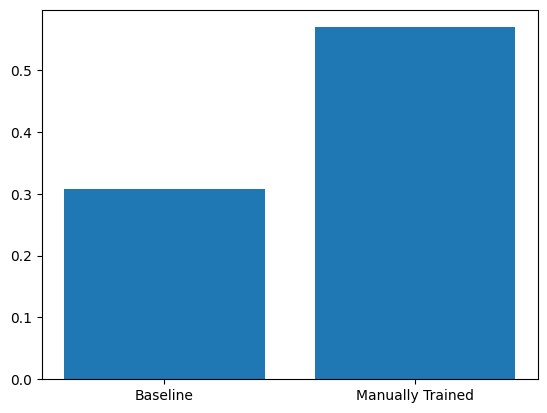

In [29]:
metrics = ["accuracy"]

# TODO: evaluate on test dataset!
trained_result = evaluate(
    untrained_model,
    test_dataloader,
    device,
    metrics
)["accuracy"]

# now, plot! do not modify the following:
results = baseline_result, trained_result
names = ["Baseline", "Manually Trained"]
make_plots(results, names)

As you can see, this model achieves an accuracy of around 55% after the first two epochs. Training it for further epochs (which you don't need to do) renders minimal improvement. To achieve better performance when training DistilBERT from scratch for this purpose, we'd need a lot more data and a lot more time (and/or compute). Fortunately, there is a better way!

## Part 3 - Finetuning a pre-trained model

Since manually training the untrained model didn't work very well, let's fine-tune a pre-trained model.

### 1. Load pre-trained model:

This time, we'll make use of a pre-trained version of DistilBERT - everything's the same as before, but the model has already been pre-trained for a language modeling task.

In [30]:
from transformers import DistilBertForSequenceClassification

# TODO: load the distilbert-base-uncased pre-trained model, use DistilBertForSequenceClassification
# from HuggingFace (transformers), read their documentation to do this.
# HINT: double-check that you have the right number of labels!
pretrained_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

# ignore the warnings printed below

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Let's give it a test run!

To motivate our need for fine-tuning/training the model on our sentiment classification task, we can see that the pre-trained model isn't particularly good at this specific task out-of-the-box. We can see this after evaluating it on the test set without fine-tuning it first.

  0%|          | 0/63 [00:00<?, ?it/s]

Baseline accuracy: 0.308
Manually trained accuracy: 0.569
Pre-trained accuracy: 0.361


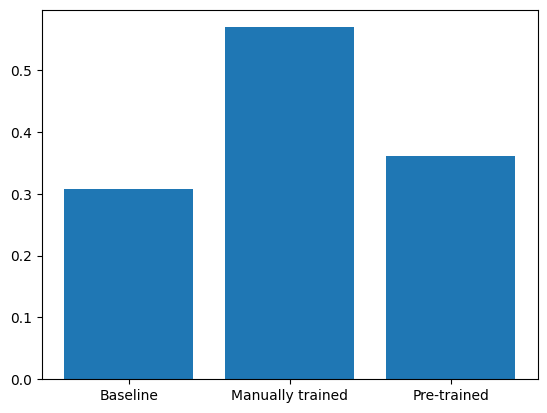

In [31]:
# we have to move the model to the device before doing anything with it!
pretrained_model.to(device)

# TODO: call evaluate on the pre-trained model!
pretrained_result = evaluate(
    pretrained_model,
    test_dataloader,
    device,
    ["accuracy"]
)["accuracy"]

# now, plot! do not modify the following:
results = [baseline_result, trained_result, pretrained_result]
names = ["Baseline", "Manually trained", "Pre-trained"]
make_plots(results, names)

As we can see, without any fine-tuning, the pre-trained model performs rather badly. This makes sense, since DistilBERT is pre-trained on a masked language modeling task, so the classifier portion of DistilBERT isn't at all trained for sentiment classification (recall the architecture and training of BERT from lecture).

### 2. Fine-tuning pre-trained model:

Rather than train the model from scratch, we'll now fine-tune the pre-trained model!
We'll fine-tune by simply running the `train` function on our pre-trained model with the training data. Fine-tune it for **2 epochs**.

In [32]:
num_epochs = 2

# TODO: use the same kind of optimizer as before, but with the pretrained model's parameters
optimizer = torch.optim.AdamW(pretrained_model.parameters(), lr=5e-5)

# this hasn't changed
lr_scheduler = get_scheduler(
    "linear",
    optimizer = optimizer,
    num_warmup_steps = 50,
    num_training_steps = len(train_dataloader) * num_epochs
)

In [33]:
torch.cuda.empty_cache()
pretrained_model.to(device)

# TODO: train!
train(
    pretrained_model,
    optimizer,
    num_epochs,
    train_dataloader,
    validation_dataloader,
    lr_scheduler,
    device
)

Epoch 1 training:


  0%|          | 0/188 [00:00<?, ?it/s]

Epoch 1 average training metrics: accuracy=0.6346666666666667
Running validation:


  0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1 validation: accuracy=0.746
Epoch 2 training:


  0%|          | 0/188 [00:00<?, ?it/s]

Epoch 2 average training metrics: accuracy=0.832
Running validation:


  0%|          | 0/63 [00:00<?, ?it/s]

Epoch 2 validation: accuracy=0.759


You should've seen a sneak-peak of the model's performance based on the validation accuracies!

### 3. Evaluating the fine-tuned model:

  0%|          | 0/63 [00:00<?, ?it/s]

Baseline accuracy: 0.308
Manually trained accuracy: 0.569
Pre-trained accuracy: 0.361
Fine-tuned accuracy: 0.772


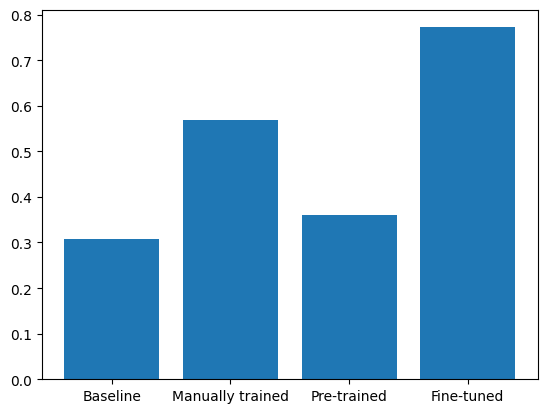

In [34]:
# TODO: evaluate the fine-tuned model on the test dataset
finetuned_result = evaluate(
    pretrained_model,
    test_dataloader,
    device,
    ["accuracy"]
)["accuracy"]

# now, plot! do not modify the following:
results = [baseline_result, trained_result, pretrained_result, finetuned_result]
names = ["Baseline", "Manually trained", "Pre-trained", "Fine-tuned"]
make_plots(results, names)

Wow! With just two epochs of training, and only 3k training examples, we can achieve ~75% accuracy (this should be attainable)! As you can see, the pre-trained (but not fine-tuned) model has a very noticeable advantage over the completely untrained one("Baseline"). Training for an additional epoch renders a slight improvement, after which the fine-tuning begins to overfit on our training set, which can be judged by comparing the average epoch training accuracies and validation accuracies.

Additionally, remember that this is the same dataset used in assignment 1, where you had to do significant pre-processing just to get the accuracy to ~65%! With ease (and less training data, since here we had a 60/20/20 split), DistilBERT has an even better performance (take this with a grain of salt, however, since we didn't perform any cross-validation).

## Part 4 - Frozen pre-trained representations

Another way to fine-tune a model is to freeze some parts of the pre-trained model during training, essentially directly transferring these representations to the new neural network. When freezing layers of a model, the weights of those layers are no longer able to update when backpropagating. Refer to the lecture on fine-tuning and frozen representations for a more detailed introduction.

We will train a pre-trained model while freezing the weights of the embeddings and first two layers of the transformer. Feel free to adapt your code from Part 3 for all of the corresponding TODOs.

In [35]:
# TODO: load the distilbert-base-uncased pre-trained model again, use DistilBertForSequenceClassification
frozen_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

# the information printed out from below may be useful for understanding which parts of the model should be frozen
for name, module in frozen_model.named_children():
    print(name, module)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


distilbert DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
        

In [36]:
from transformers import DistilBertModel
# TODO
def freeze_distilbert(distilbert: DistilBertModel) -> None:
    """
    Freezes the embeddings module and the first two transformer layers of a DistilBert model.

    Parameters:
    -----------
    distilbert : torch.nn.Module
        The model to be frozen.
    """

    # TODO: Freeze the embeddings module and first two transformer layers of the model
    for param in distilbert.embeddings.parameters():
        param.requires_grad = False

    for layer in distilbert.transformer.layer[:2]:
        for param in layer.parameters():
            param.requires_grad = False

Epoch 1 training:


  0%|          | 0/188 [00:00<?, ?it/s]

Epoch 1 average training metrics: accuracy=0.617
Running validation:


  0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1 validation: accuracy=0.745
Epoch 2 training:


...

Epoch 2 average training metrics: accuracy=0.7896666666666666
Running validation:


  0%|          | 0/63 [00:00<?, ?it/s]

Epoch 2 validation: accuracy=0.749


  0%|          | 0/63 [00:00<?, ?it/s]

Baseline accuracy: 0.308
Manually trained accuracy: 0.569
Pre-trained accuracy: 0.361
Fine-tuned accuracy: 0.772
Frozen accuracy: 0.752


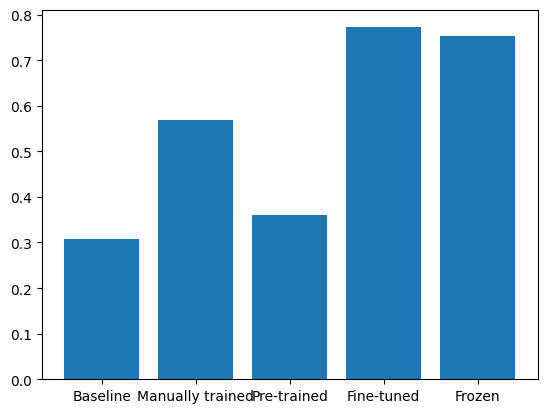

In [37]:
freeze_distilbert(frozen_model.distilbert)
frozen_model.to(device)
num_epochs = 2

# TODO: use the same kind of optimizer as before, but only with parameters that are not frozen
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, frozen_model.parameters()),
    lr=5e-5
)
lr_scheduler = get_scheduler(
    "linear",
    optimizer = optimizer,
    num_warmup_steps = 50,
    num_training_steps = len(train_dataloader) * num_epochs
)

torch.cuda.empty_cache()
frozen_model.to(device)

# TODO: train!
train(
    frozen_model,
    optimizer,
    num_epochs,
    train_dataloader,
    validation_dataloader,
    lr_scheduler,
    device
)

# TODO: evaluate the frozen model on the test dataset
frozen_result = evaluate(
    frozen_model,
    test_dataloader,
    device,
    ["accuracy"]
)["accuracy"]

# now, plot! do not modify the following:
results = [baseline_result, trained_result, pretrained_result, finetuned_result, frozen_result]
names = ["Baseline", "Manually trained", "Pre-trained", "Fine-tuned", "Frozen"]
make_plots(results, names)

## Part 5 - Conceptual Questions

1. Why might the frozen model be performing with a very similar accuracy to the fine-tuned model? Consider which parts of the model we chose to freeze.

2. Why might we prefer to use a frozen model as opposed to a fully fine-tuned model? Use quantitative observations from the training of your frozen model compared to that of your fully fine-tuned model as evidence in your answer.


3. In this assignment we've covered several methods of getting a language model to do a task:

    1. Using a pre-trained model off-the-shelf/out-of-the-box
    2. Manually training a model from scratch
    3. Fine-tuning a pre-trained model
    4. Fine-tuning a partly frozen pre-trained model.
    
    Organizations must balance various factors when considering which method to adopt in deploying language models. List at least two factors that an organization should consider, and these factors' implications for which of the above method(s) would be best.

4. BERT is trained with both a masked language modeling (MLM) objective and a next sentence prediction (NSP) objective. Since BERT was released, studies have suggested that the NSP objective doesn't do much to improve performance. Imagine you want to train a new BERT model, BERT_basic, which uses only MLM and does not use NSP. In what ways would the output of your BERT_basic’s tokenizer likely differ from that of BERT’s tokenizer?

### Answers:

1. The frozen model performs similarly to the fully fine-tuned model because only the embeddings and the first two transformer layers were frozen, while the remaining layers and classification head were still trainable. The early layers of a transformer typically learn general linguistic features such as syntax, word relationships, and basic semantic patterns during pretraining. These features transfer well across tasks and do not need to be relearned. Most of the task-specific adaptation happens in the higher layers, which were still updated during training.

2. A frozen model may be preferred because it is more computationally efficient while still achieving comparable performance. Since fewer parameters are updated during training, frozen models require less memory and computation, leading to faster training times. Additionally, freezing parts of the model can reduce the risk of overfitting, especially when working with smaller datasets. In this experiment, the frozen model achieved an accuracy of 0.752, which is very close to the fully fine-tuned model’s accuracy of 0.772. This small performance gap suggests that freezing early layers can provide a good trade-off between efficiency and accuracy, making frozen models attractive in resource-constrained settings.

3. One important factor is computational resources, including available hardware, training time, and cost. Training a model from scratch is very resource-intensive and often impractical, while fine-tuning or using frozen models is much more efficient. Another key factor is the desired level of performance. Fine-tuned models typically achieve the highest accuracy, whereas pre-trained models without task-specific training perform significantly worse. Therefore, if high accuracy is critical, fine-tuning is preferred; if resources are limited, frozen or pre-trained models may be more appropriate.

4. The tokenizer for BERT_basic would likely be largely the same as BERT’s tokenizer, since tokenization methods such as WordPiece are independent of the training objectives. However, the way inputs are structured would differ due to the absence of the next sentence prediction (NSP) objective. In standard BERT, inputs may consist of two sentences separated by a special [SEP] token, and token type embeddings are used to distinguish between them. Without NSP, BERT_basic would primarily process single sentences, so the use of sentence pairs and segment embeddings would be unnecessary. As a result, inputs would typically contain only a single sequence with [CLS] and [SEP] tokens, leading to a simpler input format, even though the underlying tokenization process remains unchanged.

# Submission Instructions

Please submit this Colab file as **three** files to Gradescope:

1.  A `.py` file: Click File > Download > Download .py
2.  A `.ipynb` file with outputs: Click Runtime > Run All, and then after all outputs are complete, click File > Download > Download .ipynb
3. A `.pdf` file of this notebook with all outputs: File > Print or Ctrl + P

Please ensure that the `.ipynb` and `.pdf` contain actual function outputs (and not leftover print statements, for instance). We will run your `.ipynb` file; if our outputs don't match the outputs in your submitted files (within reason), you will receive a 0 on this assignment.

# Frequently Asked Question (FAQ)

**Question**: Why does AdamW work in Colab but fail on the autograder for the frozen model?

**Answer**: This is an autograder compatibility issue. The grader expects AdamW to be referenced as torch.optim.AdamW, not imported directly with from torch.optim import AdamW. Use:

```optimizer = torch.optim.AdamW(...)```


Even valid PyTorch code can fail if it doesn’t match the autograder’s expectations.

---
**Question**: I’m getting a CUDA out of memory error. What can I do?

**Answer**: Try reducing memory usage by lowering the batch size

---
**Question**: Why am I getting Test Failed: Incorrect number of items in X: expected 5000, got 0?

**Answer**: The autograder expects single-line definitions for X and Y. If they span multiple lines, the grader may only evaluate the first line, resulting in empty tensors. This is a known autograder limitation—failed tests will be manually graded, so you don’t need to worry.


Last Updated: 15 Jan 2026